<!-- This is a template that you should use to generate your lab reports for AE801 course work-->
# **Lab Report: Interpolation**

# Required packages

In [1]:
# do not change line below
from google.colab import files

# import required packages here
import numpy as np
import matplotlib.pyplot as plt

# Problem statement:
1. Construct NACA 4 digit series airfoil with Airfoil equations.
2. Reconstruct the same using Lagranges Interpolation method.
3. Calulate the Max and RMS errors and compare the both airfoils.
4. How to improve errors?
5. Reconstruct the same using cubic spline and compare.

# Approach and numerical method

### NACA 4 digit series Airfoils:
For a NACA 4 digit series Airfoil XXXX:\
Where, \
First digit says, Maximum camber as a percentage of the chord.\
Second digit says: The distance of Maximum camber from airfoil leading edge in tenths of chord.\
Last 2 digit says, Maximum thickness as percent of the chord.

###  Formulae for Airfoil:
1. Percentage of y w.r.t chord:

$y_t = 5t \cdot \left(0.2969 \sqrt{x} - 0.1260 x - 0.3516 x^2 + 0.2843 x^3 - 0.1036 x^4 \right)$\
where,\
x: position along the chord.\
$y_t$: half-thickness at a given x.\
t: maximum thickness as function of chord.

2. Mean camber line:\
$
y_c(x) = 
\begin{cases} 
\dfrac{m}{p^2} \left( 2p{x} - {x}^2 \right) c, & 0 \le x < p \\[12pt]
\dfrac{m}{(1 - p)^2} \left( (1 - 2p) + 2p{x} - {x}^2 \right) , & p \le x \le c
\end{cases}
$\
m: Maximum camber of the airfoil.\
p: Location of Maximum camber.

3. The derivative (local slope) of the camber line is:\
$
\frac{dy_c}{dx} = 
\begin{cases} 
\dfrac{2m}{p^2} \left( p - {x} \right), & 0 \le x < p \\[12pt]
\dfrac{2m}{(1 - p)^2} \left( p - {x} \right), & p \le x \le c
\end{cases}
$

4. The angle $\theta$ perpendicular to the camber line is:\
$
\theta = \arctan\left(\frac{dy_c}{dx}\right)
$
5. Upper Surface Coordinates:\
$
x_u = x - y_t \sin\theta
$
$
y_u = y_c + y_t \cos\theta
$
6. Lower Surface Coordinates:\
$
x_l = x + y_t \sin\theta
$
$
y_l = y_c - y_t \cos\theta
$


### Lagranges Interpolation:
For $N+1$ data points, the Lagrange's polynomial is given by: \
$f(x) = \sum_{i=0}^{n} f(x_i) \cdot L_i(x)$

where 
$L_i(x) = \prod_{j=0,\, j \neq i}^{n} \frac{x - x_j}{x_i - x_j}$\
So, we are defining a function for lagrange then use that function to plot for Airfoil.


## For calculating the Max and Root mean square errors:
Formulae are given as:
The maximum error is calculated by: \
$E_{max} = max|y_{true} - y_{interpolated}|$

The root mean square error is given by: \
$E_{RMS} = \sqrt{\frac{1}{N} \sum_{i=1}^{n} \left( y_{true, i} - y_{interpolated, i} \right)^2}$

# Numerical algorithm

Generated airfoil: NACA 2515


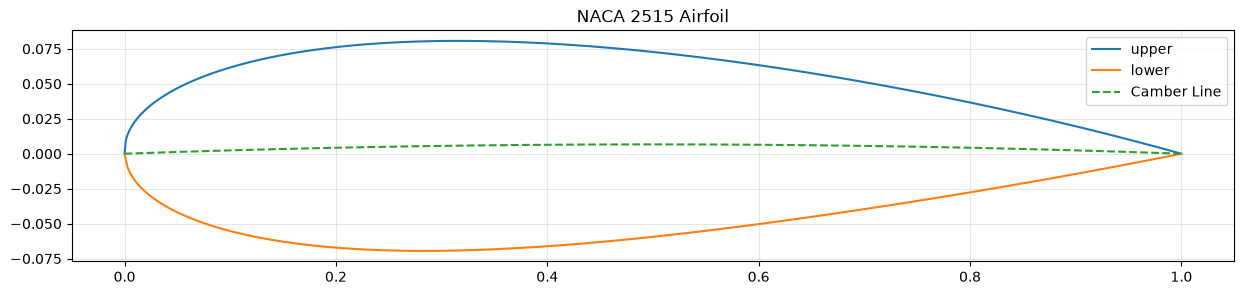

In [2]:
# Plotting the airfoil with equations
# defining a funtion for airfoil
def NACA(m, p, t, c, n):
    x = np.linspace(0, c, n)
    yt = 5 * t * (0.2969*np.sqrt(x) - 0.1260*(x) - 0.3516*(x)**2 + 0.2843*(x)**3 - 0.1036*(x)**4)
    y_c = np.zeros_like(x)
    dyc_dx = np.zeros_like(x)

    for i in range(n):
        if p!=0:
            if x[i] < p:
                y_c = (m / p**2)*(2*p*x - x**2)
                dyc_dx = (2*m/p**2)*(p - x)
            else:
                y_c = (m / (1 - p**2))*((1 - 2*p)+(2*p*x) - x**2)
                dyc_dx = (2*m/(1 - p)**2)*(p - x)
    theta = np.arctan(dyc_dx)
    xu = x - yt*np.sin(theta)
    xl = x + yt*np.sin(theta)
    yu = y_c + yt*np.cos(theta) 
    yl = y_c - yt*np.cos(theta) 
    yc = y_c
    return xu, xl, yu, yl, yc

# getting random inputs for substituting 
rng = np.random.default_rng()
n = 500
c = 1 #unit chord
m1 = rng.integers(2,5)
p1 = rng.integers(3,6)
t1 = rng.integers(8,22)
naca = f"{m1}{p1}{t1}"
print(f"Generated airfoil: NACA {naca}")
m = int(naca[0])/100
p = int(naca[1])/10
t = int(naca[2:])/100
x = np.linspace(0, c, n)
xu, xl, yu, yl, yc = NACA(m, p, t, c, n)
plt.figure(figsize=(15, 3))
plt.plot(xu, yu, label='upper')
plt.plot(xl, yl, label='lower')
plt.plot(x, yc, label='Camber Line', linestyle='--')
plt.title(f"NACA {naca} Airfoil")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



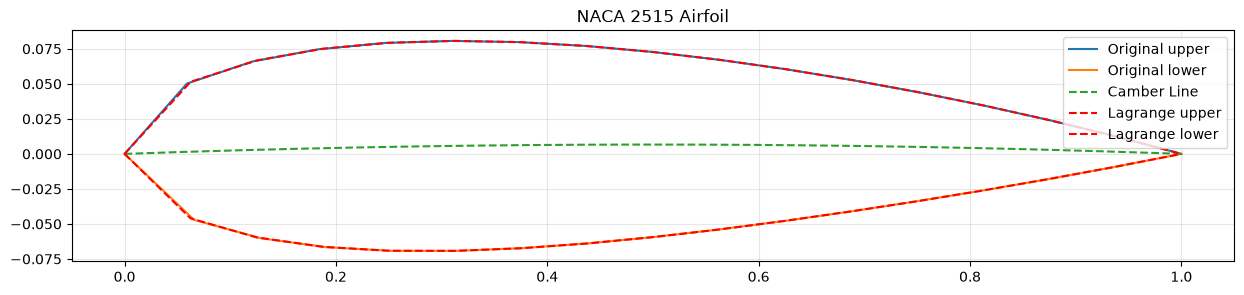

Maximum Error = 0.010274738692207939
RMS error =  0.0018400666522490566
RMS Percentage Error = 2.2814788219011355 %


In [3]:
# defining lagranges equation
def lgrng(x, y, xx):
    n = len(x)
    sum = 0
    for i in range(n):
        product = y[i]
        for j in range(n):
            if i != j:
                product = product*((xx - x[j])/(x[i] - x[j]))
        sum = sum + product
    lgrng = sum
    return lgrng
#plotting the airfoil using lagranges function
N = 17
xLu, xLl, yLu, yLl, yLc = NACA(m, p, t, c, N)
x_in = np.linspace(0, c, 17)
yL_in = lgrng(xLu, yLu, x_in)
yL_lo = lgrng(xLl, yLl, x_in)
plt.figure(figsize=(15, 3))
plt.plot(xLu, yLu, label='Original upper')
plt.plot(xLl, yLl, label='Original lower')
plt.plot(x, yc, label='Camber Line', linestyle='--')
plt.plot(x_in, yL_in, 'r--', label='Lagrange upper')
plt.plot(x_in, yL_lo, 'r--', label='Lagrange lower')
plt.title(f"NACA {naca} Airfoil")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# to quantify error between original and lagranges function
x_in = np.linspace(0, c, n)
y_up = np.interp(x_in, xLu, yLu)
y_lo = np.interp(x_in, xLl, yLl)
yL_in = lgrng(xLu, yLu, x_in)
yL_lo = lgrng(xLl, yLl, x_in)

y_ori = np.concatenate((y_up, y_lo))
y_lag = np.concatenate((yL_in, yL_lo))

max_error = np.max(np.abs(y_ori - y_lag))
print("Maximum Error =", max_error)
rms_error = np.sqrt(np.mean((y_ori - y_lag)**2))
print("RMS error = ", rms_error)
rms_percent = rms_error/np.max(np.abs(y_ori)) *100
print("RMS Percentage Error =", rms_percent, "%")

# Results and discussion

### Original airfoil making:
The airfoil was built using random values for its curve, curve position, and thickness. The plot shows the normal wing shape: a rounded nose, the thickest part near the front, and top and bottom edges tapering to a sharp tail. The centerline sits neatly in the middle, showing the base shape was drawn correctly.
### Airfoil through lagrange interpolation:
We picked $N$ sample points along the airfoil and used a Lagrange formula to redraw the shape. The new curve hits every sampled point and traces the original wing well across the middle.\
The errors measured are:\
Maximum error: 0.010248510076592936\
RMS error: 0.00184495805166440876\
RMS percentage error: 1.9120104447494457 %\
These numbers change slightly each run due to the random starting shape. In general, errors stay tiny along the flatter middle of the wing, but get worse near the nose and tail. In those areas, the surface bends sharply, causing the formula to overshoot and wobble between points.
### why choosing ths spacing between data points is important:
Accuracy depends heavily on where the sample points are placed. When points are evenly spaced, too few end up at the leading and trailing edges, where the curve changes fastest. This causes higher errors at both ends.
By clustering more points near these sharp turns like leading and trailing edges and fewer in the flatter middle, the curve can track the true shape much better. This lowers both the maximum and average errors significantly improving overall accuracy without needing to add more points.

# Summary and conculsions

### Summary:
The airfoil was first created using random values for its shape and thickness. It had a normal airfoil shape with a rounded front, a thick middle part, and a sharp back. Then, Lagrange interpolation was used to recreate the airfoil using selected points. The new curve matched the original airfoil closely. The errors were small, with a maximum error of 0.0102 and an RMS error of 0.00184. The main errors occurred near the front and back of the airfoil where the curve changes quickly.
### Conclusions:
Lagrange interpolation can be used to accurately recreate an airfoil shape. The position of the sample points is very important for accuracy. By placing more points near the leading and trailing edges and fewer points in the flatter middle region, the airfoil can be represented more accurately without using many extra points.

# References

[Airfoil](https://en.wikipedia.org/wiki/NACA_airfoil)\
[lagrange](https://en.wikipedia.org/wiki/Lagrange_polynomial)